In [1]:
import os
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_PATH = r"C:\Users\dhruv\OneDrive\Documents\cancer (1)"
IMG_SIZE = 64

In [3]:
def load_data(path):
    X, y = [], []

    for label in ['0', '1']:   # 0 = Non-cancer, 1 = Cancer
        folder = os.path.join(path, label)
        images = glob(os.path.join(folder, "*"))

        print(f"{label} → {len(images)} images")

        for img_path in images:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(int(label))

    return np.array(X), np.array(y)

X, y = load_data(DATASET_PATH)

y = y.astype(int)  # ✅ FIX

print("Total Data:", len(X))
print("Class Distribution:", np.bincount(y))

0 → 0 images
1 → 0 images
Total Data: 0
Class Distribution: []


In [4]:
def load_data(path):
    X, y = [], []

    print("🔍 Scanning nested dataset...")

    for main_folder in os.listdir(path):
        main_path = os.path.join(path, main_folder)

        if os.path.isdir(main_path):

            for label in ['0', '1']:  # 0 = Non-cancer, 1 = Cancer
                label_path = os.path.join(main_path, label)

                if os.path.exists(label_path):
                    images = glob(os.path.join(label_path, "*"))

                    print(f"{main_folder}/{label} → {len(images)} images")

                    for img_path in images:
                        img = cv2.imread(img_path)
                        if img is not None:
                            img = cv2.resize(img, (64, 64))
                            X.append(img)
                            y.append(int(label))

    return np.array(X), np.array(y).astype(int)

In [5]:
X, y = load_data(DATASET_PATH)

print("Total Data:", len(X))
print("Class Distribution:", np.bincount(y))

🔍 Scanning nested dataset...
10253/0 → 479 images
10253/1 → 70 images
10254/0 → 772 images
10254/1 → 76 images
10255/0 → 181 images
10255/1 → 91 images
10256/0 → 351 images
10256/1 → 117 images
10257/0 → 427 images
10257/1 → 208 images
10258/0 → 422 images
10258/1 → 108 images
10259/0 → 1434 images
10259/1 → 31 images
10260/0 → 928 images
10260/1 → 361 images
10261/0 → 590 images
10261/1 → 56 images
10262/0 → 1053 images
10262/1 → 754 images
10264/0 → 617 images
10264/1 → 587 images
10268/0 → 2086 images
10268/1 → 23 images
10269/0 → 904 images
10269/1 → 250 images
10272/0 → 2150 images
10272/1 → 25 images
10273/0 → 811 images
10273/1 → 1211 images
10274/0 → 659 images
10274/1 → 219 images
10275/0 → 297 images
10275/1 → 760 images
10276/0 → 591 images
10276/1 → 348 images
10277/0 → 785 images
10277/1 → 170 images
10278/0 → 1068 images
10278/1 → 91 images
10279/0 → 1267 images
10279/1 → 427 images
10282/0 → 1835 images
10282/1 → 198 images
10285/0 → 1011 images
10285/1 → 222 images
1028

In [6]:
X_0 = X[y == 0]
X_1 = X[y == 1]

count_0 = len(X_0)
count_1 = len(X_1)

print("Before:", count_0, count_1)

# ⚡ Reduce dataset for speed (VERY IMPORTANT)
limit = min(count_0, count_1, 80000)

X_0 = X_0[:limit]
X_1 = X_1[:limit]

X_bal = np.concatenate([X_0, X_1])
y_bal = np.array([0]*len(X_0) + [1]*len(X_1))

print("After:", np.bincount(y_bal))

Before: 198738 78786
After: [78786 78786]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    stratify=y_bal,
    random_state=42
)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (126057, 64, 64, 3)
Test: (31515, 64, 64, 3)


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0000079329821667), 1: np.float64(0.9999920671436957)}


In [9]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,64,3)),

    # 🔥 Data Augmentation (helps accuracy)
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,273 (430.75 KB)

 Trainable params: 110,081 (430.00 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 437s 137ms/step - accuracy: 0.8300 - loss: 0.3981 - val_accuracy: 0.6391 - val_loss: 0.9815
Epoch 2/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 299s 95ms/step - accuracy: 0.8471 - loss: 0.3624 - val_accuracy: 0.6968 - val_loss: 0.6609
Epoch 3/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 300s 95ms/step - accuracy: 0.8555 - loss: 0.3432 - val_accuracy: 0.8519 - val_loss: 0.3600
Epoch 4/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 293s 93ms/step - accuracy: 0.8650 - loss: 0.3233 - val_accuracy: 0.8605 - val_loss: 0.3180
Epoch 5/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 299s 95ms/step - accuracy: 0.8687 - loss: 0.3145 - val_accuracy: 0.8569 - val_loss: 0.3435
Epoch 6/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 297s 94ms/step - accuracy: 0.8699 - loss: 0.3091 - val_accuracy: 0.8083 - val_loss: 0.4769
Epoch 7/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 296s 94ms/step - accuracy: 0.8746 - loss: 0.2996 - val_accuracy: 0.8147 - val_loss: 0.4493
Epoch 8/20
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 294s 93ms/step - accuracy:

In [11]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

985/985 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step
📊 Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.88     15758
           1       0.89      0.87      0.88     15757

    accuracy                           0.88     31515
   macro avg       0.88      0.88      0.88     31515
weighted avg       0.88      0.88      0.88     31515



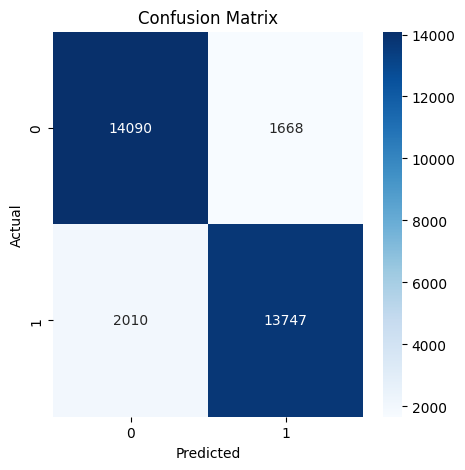

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

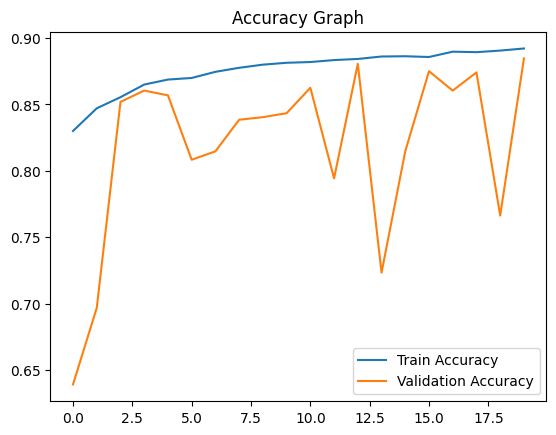

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [14]:
import cv2
import numpy as np

def predict_image(path=r"C:\Users\dhruv\OneDrive\Documents\cancer (1)\9173\1\9173_idx5_x1501_y2001_class1.png"):
    img = cv2.imread(path)
    
    if img is None:
        print("❌ Image not found. Check path!")
        return
    
    img = cv2.resize(img, (64,64))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    print("Probability:", pred)

    if pred > 0.5:
        print("🛑 Cancer Detected")
    else:
        print("✅ No Cancer")

# 🔥 CALL FUNCTION
predict_image()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Probability: 0.948038
🛑 Cancer Detected


In [15]:
from tensorflow.keras.models import load_model

# Step 1: Load old model
print("🔄 Loading old model...")
model = load_model("cancer_model.h5", compile=False)

# Step 2: Save in compatible format
print("💾 Saving fixed model...")
model.save("cancer_model_fixed.h5")

print("✅ Model fixed successfully!")

🔄 Loading old model...


💾 Saving fixed model...
✅ Model fixed successfully!


In [16]:
model.save("cancer_model.h5")

In [20]:
from tensorflow.keras.models import load_model

model = load_model("cancer_model.h5", compile=False)
model.save("cancer_model.h5")

print("✅ Model fixed and saved")

✅ Model fixed and saved


In [21]:
from tensorflow.keras.models import load_model

model = load_model("cancer_model.h5", compile=False)

# SAVE AS NEW FILE 🔥
model.save("cancer_model_v2.h5")

print("✅ New model saved")

✅ New model saved


In [23]:
from tensorflow.keras.models import load_model
from tensorflow.keras import Sequential

# Load old model
model = load_model("cancer_model_v2.h5", compile=False)

# 🔥 Rebuild clean model (fixes config)
model = Sequential.from_config(model.get_config())
model.set_weights(model.get_weights())

# Save again
model.save("cancer_model_final.h5")

print("✅ FINAL MODEL READY")

✅ FINAL MODEL READY
